In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import random
from EMDPM.model_generator import generate_logistic_model, get_adjacency_matrix, create_patient_list
from EMDPM.synthetic_data_generator import generate_synthetic_data
from EMDPM.visualization import * 
from EMDPM.utils import *
from EMDPM.subtyping_em_transformer import SubtypingEM

np.set_printoptions(precision=4)

In [2]:
# data params
n_biomarkers = 10
t_max = 40 # was 20
t_span = np.linspace(0, t_max, 8000)
noise_level = 0.0
n_patients = 150 # was 200
n_patient_obs = 3
n_subtypes = 2 #3,4,5
rng = np.random.RandomState(75)

For subtype data generation: different sets of trajectories are generated for each subtype. 
- K is held constant for each subtype
- f and scalar_K are different for each subtype

- removed variablity in time point, now they are in intervals of integer years to mirror ppmi data.
- only one copy of beta now generated instead of three identical copies.

SUBTYPE 0:
f: [0.     0.0091 0.0118 0.0281 0.013  0.0072 0.0097 0.0121 0.0127 0.    ]
a = 3.2757608804769824, b = 0.6596422758944243


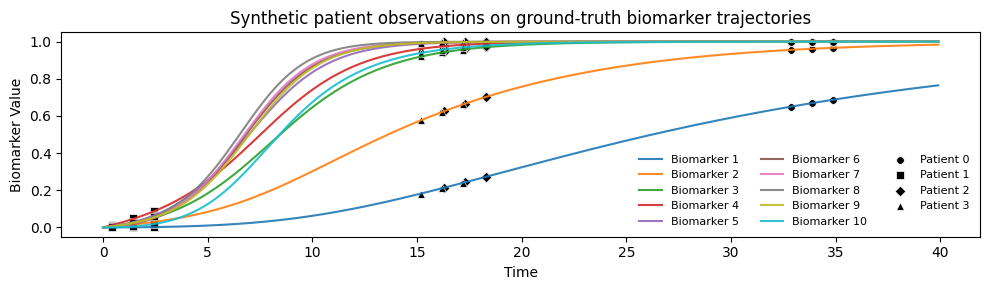

SUBTYPE 1:
f: [0.     0.     0.0138 0.0168 0.0131 0.     0.0065 0.0121 0.0062 0.0085]
a = 2.243319199025421, b = 8.1898722071885


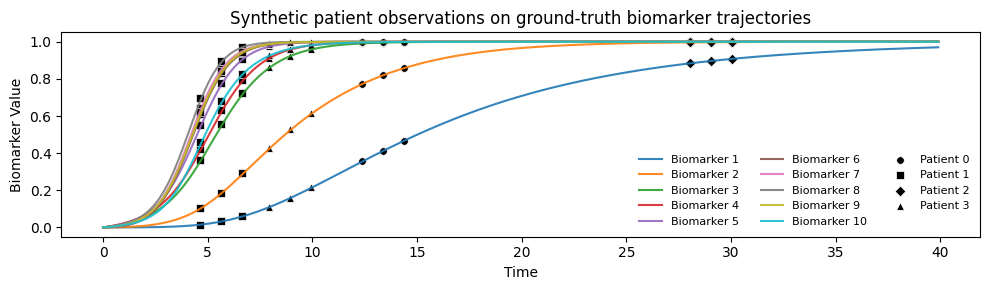

In [3]:
K = get_adjacency_matrix("random_offdiag", n_biomarkers, np.random.RandomState(75))

scalar_K_list = [0.25, 0.50]
f_list = []
for _ in range(n_subtypes):
    f_list.append(rng.gamma(shape=2, scale=0.005, size=n_biomarkers))

X = []
y = []

for subtype in range(n_subtypes):
    print(f"SUBTYPE {subtype}:")
    
    
    t, x_true, K, x0, f, scalar_K  = generate_logistic_model(n_biomarkers = n_biomarkers,
                                                             scalar_K = scalar_K_list[subtype],
                                                             t_max = t_max,
                                                             K = K,
                                                             f = f_list[subtype])

    print(f"f: {f}")
    
    df, cog_a, cog_b = generate_synthetic_data(
        n_biomarkers = n_biomarkers,
        t_max = t_max, 
        noise_level = noise_level,
        n_patients = n_patients,
        n_patient_obs = n_patient_obs,
        x_true=x_true, 
        t=t,
        rng = np.random.RandomState(75 + subtype),
    )

    plot_true_observations(df, t, x_true, patient_idx=[0,1,2,3])

    biomarker_cols = [col for col in df.columns if col.startswith("biomarker_")]

    X_obs = df[biomarker_cols].values   # (n_obs, n_biomarkers)
    dt = df["dt"].values                # (n_obs,)
    ids = df["patient_id"].values + subtype * n_patients # (n_obs,),  `+ subtype * n_patients` is for ensuring all ids are unique
    cog = df["cognitive_score"].values  # (n_obs,)
    beta_true = df["beta_true"].values  # (n_obs)
    
    #print(f"dt shape: {dt.shape}\nids shape: {ids.shape}\ncog shape: {cog.shape}\nbeta shape: {beta_true.shape}")
    #print(beta_true)
    
    X_subtype = create_patient_list(X_obs, ids, dt, cog, initial_beta=None) # TODO: ADD THE FUCKING TRUE LABELS
    
    for p in X_subtype: # tag each patient with true subtype for later eval
        p["subtype_true"] = int(subtype)
    X += X_subtype # pythonic concatenate list syntactic sugar
    
    y.append(beta_true[::n_patient_obs] )
    #  print(beta_true[::n_patient_obs][0:10])
    
X = np.asarray(X)
y = np.concatenate(y)

# print(len(X))
# print(len(y))#, y)
# print(y)

## Testing the new SubtypingEM algorithm

The SubtypingEM algorithm performs:
1. Global s parameter estimation
2. Cluster assignment (hard assignment for now)
3. Cluster-level f and scalar_K estimation
4. Patient-level beta estimation

This is all done in a single fit() call!

Fitting SubtypingEM...


  0%|          | 0/50 [00:00<?, ?it/s]

(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976
(10,) (10, 10) (4000,) 1.1120617868837976


  2%|▏         | 1/50 [00:07<05:57,  7.29s/it]

(10,) (10, 10) (4000,) 2.580412458904906
(10,) (10, 10) (4000,) 2.580412458904906
(10,) (10, 10) (4000,) 2.580412458904906
(10,) (10, 10) (4000,) 2.580412458904906
(10,) (10, 10) (4000,) 2.580412458904906


...

(10,) (10, 10) (4000,) 0.7280487277262729
(10,) (10, 10) (4000,) 0.7280487277262729
(10,) (10, 10) (4000,) 0.7280487277262729
(10,) (10, 10) (4000,) 0.7280487277262729


 74%|███████▍  | 37/50 [05:58<02:21, 10.92s/it]

(10,) (10, 10) (4000,) 0.7280487277262729
(10,) (10, 10) (4000,) 0.7280487277262729
(10,) (10, 10) (4000,) 0.7280487277262729


 74%|███████▍  | 37/50 [06:13<02:11, 10.10s/it]



Fitting complete!


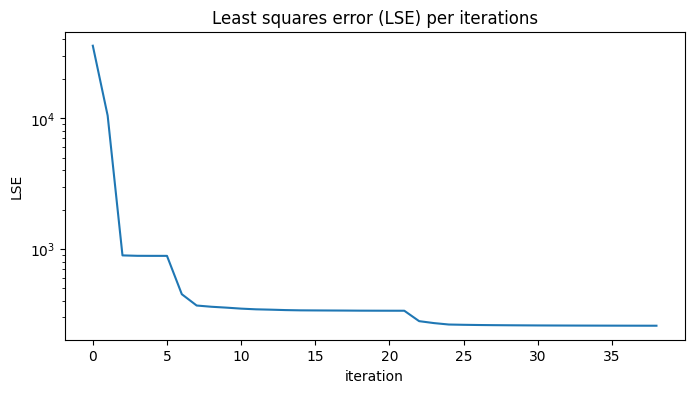

In [4]:
# Initialize f for subtyping EM
f_init = initialize_f_eigen(K=K)
if isinstance(f_init, list):
    f_init = f_init[0]

# Create and fit SubtypingEM
subtyping_em = SubtypingEM(
    K=K,
    initial_f=f_init,
    n_subtypes=n_subtypes,
    jac_toggle=True,
    max_iter=50,
    t_max=t_max,
    step=0.01,
    epsilon=1e-1,
    lambda_f=1.0,
    lambda_cog=0.01,
    lambda_scalar=0.3,
    verbose=1,
    rng=np.random.default_rng(75)
)

print("Fitting SubtypingEM...")
subtyping_em.fit(X)
print("\nFitting complete!")

# Plot LSE history
plot_lse(subtyping_em.lse_history)

In [5]:
# Print cluster parameters
print("=== CLUSTER PARAMETERS ===")
for subtype in range(n_subtypes):
    print(f"\nCluster {subtype}:")
    print(f"  f: {subtyping_em.cluster_f[subtype]}")
    print(f"  scalar_K: {subtyping_em.cluster_scalar_K[subtype]:.6f}")

print(f"\nGlobal s: {subtyping_em.final_s}")
print(f"\nFinal LSE: {subtyping_em.lse_history[-1]:.6f}")

# Store for later use
final_s = subtyping_em.final_s.copy()


=== CLUSTER PARAMETERS ===

Cluster 0:
  f: [0.0031 0.0021 0.0013 0.0153 0.0266 0.0016 0.0043 0.0384 0.0009 0.0011]
  scalar_K: 0.728049

Cluster 1:
  f: [0.0018 0.     0.     0.     0.     0.     0.     0.     0.     0.    ]
  scalar_K: 0.251671

Global s: [0.4551 0.6727 0.803  0.8238 0.8415 0.8459 0.8494 0.857  0.8456 0.8095]

Final LSE: 258.883375


=== PLOTTING CLUSTER TRAJECTORIES ===


/home/dsemchin/Progression_models_simulations/EMDPM/visualization.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


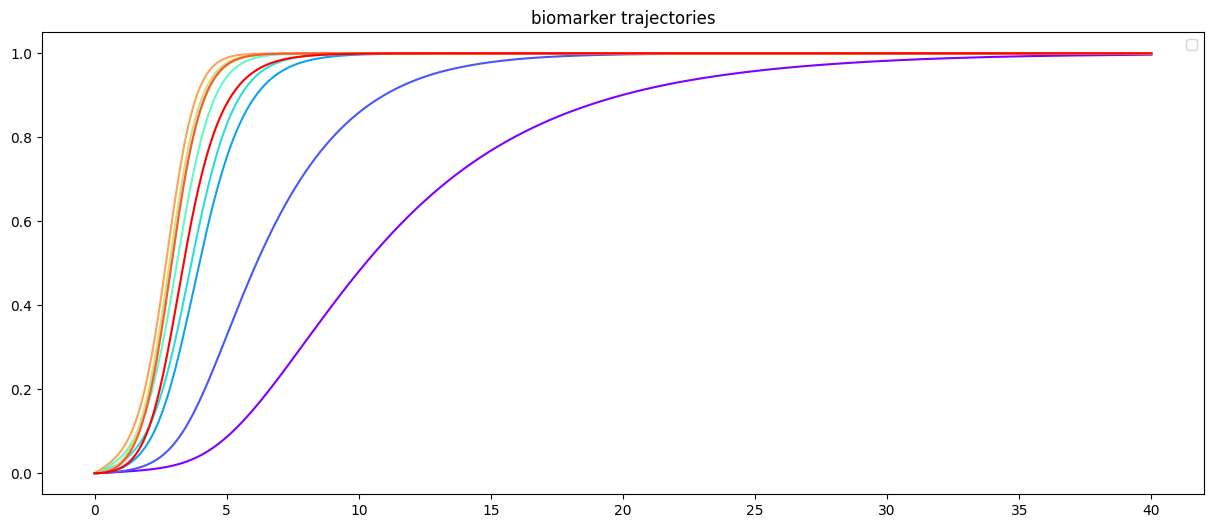

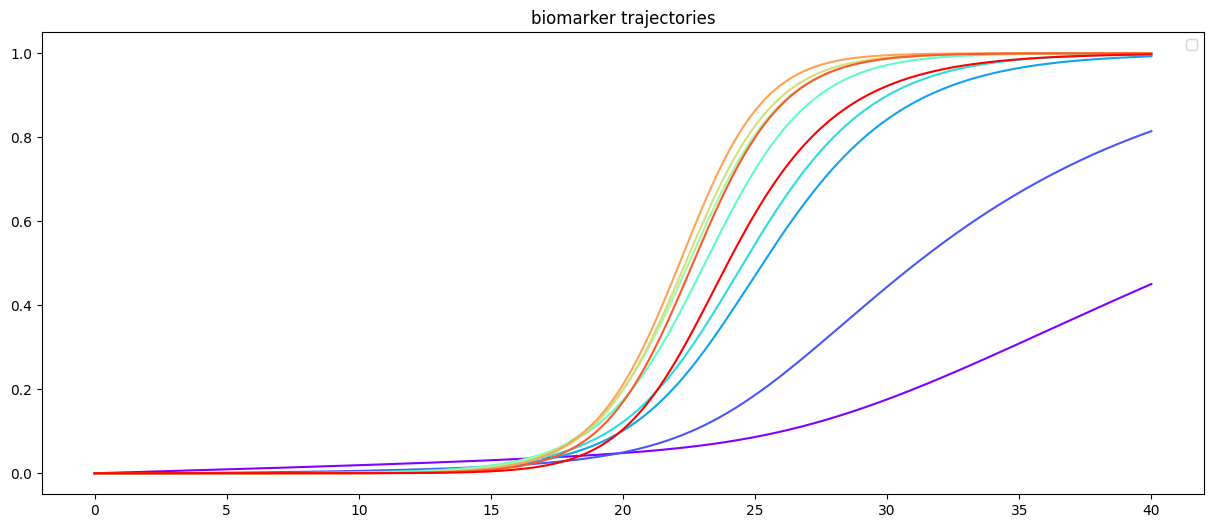

In [8]:

# Plot cluster trajectories
print("=== PLOTTING CLUSTER TRAJECTORIES ===")
for subtype in range(n_subtypes):
    f_cluster = subtyping_em.cluster_f[subtype]
    scalar_K_cluster = subtyping_em.cluster_scalar_K[subtype]
    cluster_trajectory = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_cluster,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_cluster
    )
    plot_biomarker_trajectories(
        biom_trajectories=cluster_trajectory,
        t_span=t_span,
        n_biomarkers=n_biomarkers,
    )

## Cluster Assignment Evaluation

Let's evaluate how well the algorithm recovered the true subtypes.

In [ ]:
# Get predicted cluster assignments
assignments_pred = subtyping_em.final_assignments

# Extract true assignments from patient data
assignments_true = np.array([p["subtype_true"] for p in X])

# Calculate assignment accuracy
from sklearn.metrics import adjusted_rand_score, confusion_matrix, classification_report

print("=== CLUSTER ASSIGNMENT EVALUATION ===")
print(f"True assignments distribution: {np.bincount(assignments_true)}")
print(f"Predicted assignments distribution: {np.bincount(assignments_pred)}")

# Adjusted Rand Index
ari = adjusted_rand_score(assignments_true, assignments_pred)
print(f"\nAdjusted Rand Index: {ari:.4f}")

# Confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(assignments_true, assignments_pred))

# Classification report
print("\nClassification Report:")
print(classification_report(assignments_true, assignments_pred))

# Store assignments in patient dicts for later use
for i, patient in enumerate(X):
    patient["subtype_pred"] = int(assignments_pred[i])
    patient["beta_pred"] = float(subtyping_em.beta_history[i, -1])

Estimating beta values:   0%|          | 0/300 [00:00<?, ?it/s]

Estimating beta values: 100%|██████████| 300/300 [00:01<00:00, 244.37it/s]

<class 'numpy.ndarray'> <class 'dict'>
dict_keys(['id', 'X_obs', 'dt', 'cog', 'subtype_true', 'beta_pred', 'f_init', 's_init', 'scalar_K_init'])


In [ ]:
# Plot assignment history to see convergence
import matplotlib.pyplot as plt

if hasattr(subtyping_em, 'assignment_history'):
    plt.figure(figsize=(12, 6))
    for patient_idx in range(min(10, len(X))):  # Plot first 10 patients
        plt.plot(subtyping_em.assignment_history[patient_idx, :], 
                marker='o', markersize=3, alpha=0.6, label=f'Patient {patient_idx}')
    plt.xlabel('Iteration')
    plt.ylabel('Cluster Assignment')
    plt.title('Cluster Assignment History (First 10 Patients)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Plot assignment stability
assignment_changes = np.sum(np.diff(subtyping_em.assignment_history, axis=1) != 0, axis=0)
plt.figure(figsize=(10, 4))
plt.plot(assignment_changes, marker='o')
plt.xlabel('Iteration')
plt.ylabel('Number of Assignment Changes')
plt.title('Cluster Assignment Stability Across Iterations')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Fitting subject thetas: 100%|██████████| 300/300 [05:28<00:00,  1.10s/it]

SubjectEM completed. mean |Δf| = 0.064881


In [ ]:
# Compare true vs predicted cluster parameters
print("=== COMPARING TRUE vs PREDICTED PARAMETERS ===")
print("\nTrue Parameters (from data generation):")
for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  f: {f_list[subtype]}")
    print(f"  scalar_K: {scalar_K_list[subtype]}")

print("\nPredicted Parameters (from SubtypingEM):")
for subtype in range(n_subtypes):
    print(f"\nSubtype {subtype}:")
    print(f"  f: {subtyping_em.cluster_f[subtype]}")
    print(f"  scalar_K: {subtyping_em.cluster_scalar_K[subtype]:.6f}")

print(f"\nGlobal s: {subtyping_em.final_s}")

dict_keys(['id', 'X_obs', 'dt', 'cog', 'subtype_true', 'beta_pred', 'f_init', 's_init', 'scalar_K_init', 'final_f', 'final_s', 'final_scalar_K', 'delta_f', 'delta_s', 'delta_scalar_K', 'X_pred_subject'])


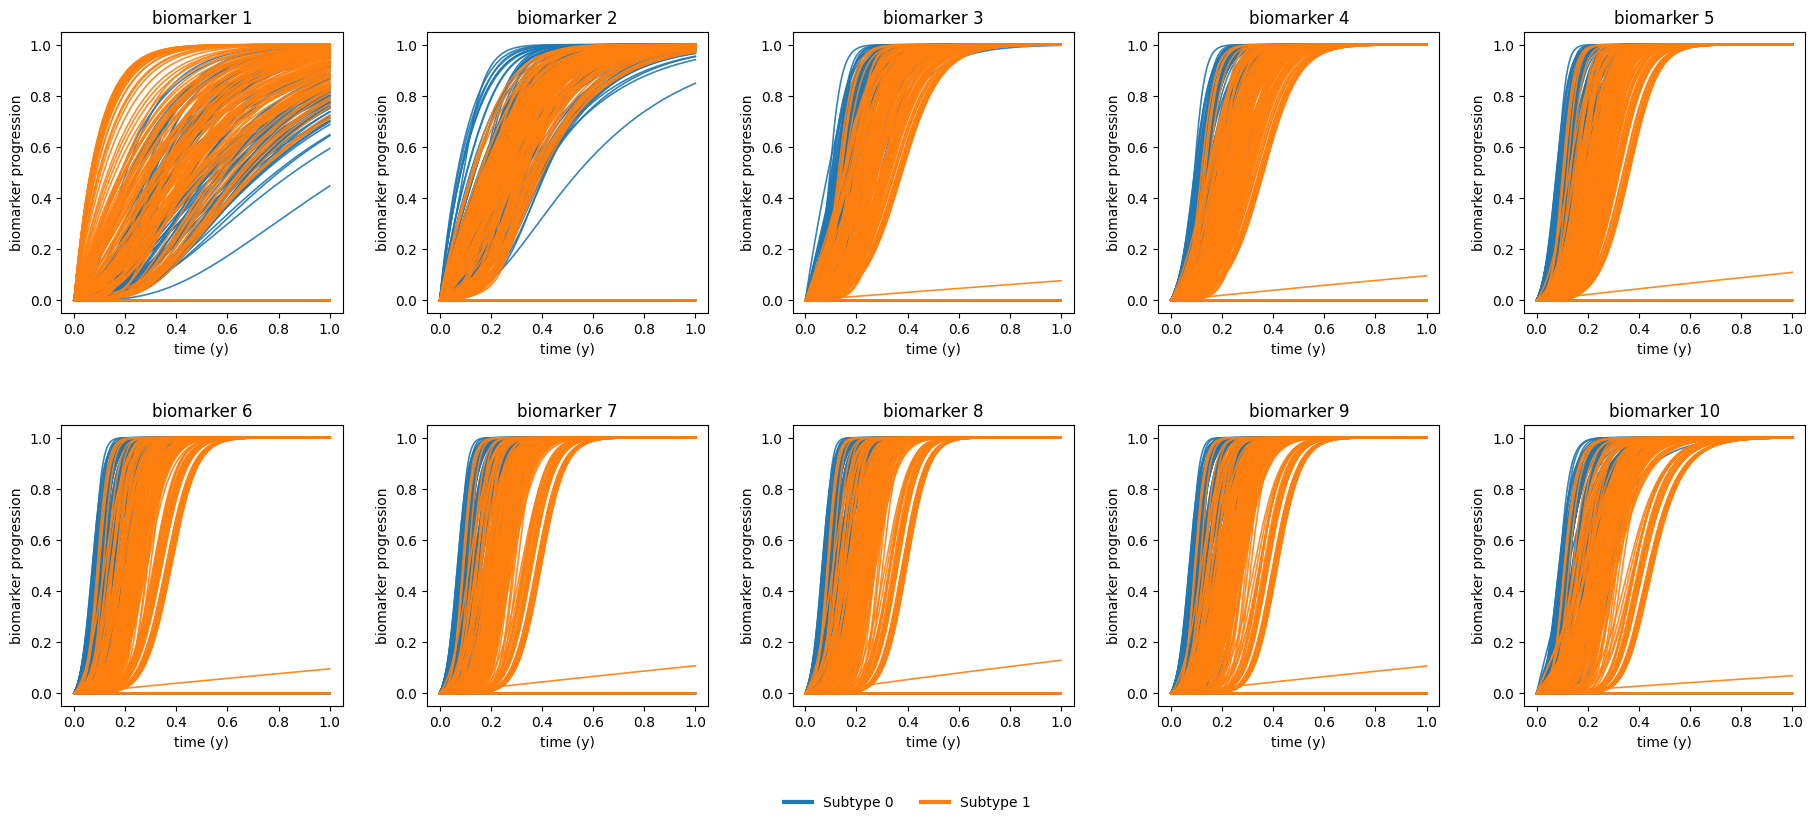

In [ ]:
# Plot patient trajectories colored by predicted cluster
plot_patient_trajectories_by_biomarker(X, biomarker_indices=list(range(n_biomarkers)))

# Also plot by true vs predicted assignments
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot by true assignments
for subtype in range(n_subtypes):
    mask = assignments_true == subtype
    for i in np.where(mask)[0][:5]:  # Plot first 5 patients per cluster
        patient = X[i]
        for b in range(n_biomarkers):
            axes[0].plot(patient["dt"], patient["X_obs"][:, b], 
                        'o', alpha=0.5, label=f'Biomarker {b}' if subtype == 0 and i == np.where(mask)[0][0] else '')
axes[0].set_title('True Subtypes')
axes[0].set_xlabel('Time (dt)')
axes[0].set_ylabel('Biomarker Value')

# Plot by predicted assignments
for subtype in range(n_subtypes):
    mask = assignments_pred == subtype
    for i in np.where(mask)[0][:5]:  # Plot first 5 patients per cluster
        patient = X[i]
        for b in range(n_biomarkers):
            axes[1].plot(patient["dt"], patient["X_obs"][:, b], 
                        'o', alpha=0.5, label=f'Biomarker {b}' if subtype == 0 and i == np.where(mask)[0][0] else '')
axes[1].set_title('Predicted Subtypes')
axes[1].set_xlabel('Time (dt)')
axes[1].set_ylabel('Biomarker Value')

plt.tight_layout()
plt.show()

In [ ]:
# Visualize cluster separation using cluster parameters
# Since we have cluster-level parameters, we can visualize how well separated they are

print("=== CLUSTER PARAMETER SEPARATION ===")

# Create feature matrix from cluster parameters
# Each patient gets assigned to a cluster, so we can use cluster parameters as features
n_patients = len(X)
n_features = n_biomarkers + 1  # f (n_biomarkers) + scalar_K (1)

features_cluster = np.zeros((n_patients, n_features))
for i in range(n_patients):
    subtype = assignments_pred[i]
    features_cluster[i, :n_biomarkers] = subtyping_em.cluster_f[subtype]
    features_cluster[i, n_biomarkers] = subtyping_em.cluster_scalar_K[subtype]

# Plot PCA of cluster parameters
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_cluster)
pca = PCA(n_components=2)
features_pca = pca.fit_transform(features_scaled)

plt.figure(figsize=(10, 5))

# Plot by true subtype
plt.subplot(1, 2, 1)
for subtype in range(n_subtypes):
    mask = assignments_true == subtype
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
               label=f'True Subtype {subtype}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('True Subtypes')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot by predicted subtype
plt.subplot(1, 2, 2)
for subtype in range(n_subtypes):
    mask = assignments_pred == subtype
    plt.scatter(features_pca[mask, 0], features_pca[mask, 1], 
               label=f'Predicted Subtype {subtype}', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Predicted Subtypes')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"PCA explained variance: {pca.explained_variance_ratio_}")


((300, 21), (300,))

In [ ]:
# Summary statistics and final evaluation
print("=== FINAL SUMMARY ===")
print(f"\nTotal patients: {len(X)}")
print(f"Number of subtypes: {n_subtypes}")
print(f"Final LSE: {subtyping_em.lse_history[-1]:.6f}")
print(f"Initial LSE: {subtyping_em.lse_history[0]:.6f}")
print(f"LSE improvement: {subtyping_em.lse_history[0] - subtyping_em.lse_history[-1]:.6f}")

# Cluster sizes
print("\nCluster sizes (predicted):")
for subtype in range(n_subtypes):
    size = np.sum(assignments_pred == subtype)
    print(f"  Cluster {subtype}: {size} patients ({100*size/len(X):.1f}%)")

# Parameter recovery error
print("\n=== PARAMETER RECOVERY ERROR ===")
for subtype in range(n_subtypes):
    # Match predicted cluster to true cluster (simple matching for now)
    # In practice, you'd need to handle label permutation
    f_true = f_list[subtype]
    f_pred = subtyping_em.cluster_f[subtype]
    scalar_K_true = scalar_K_list[subtype]
    scalar_K_pred = subtyping_em.cluster_scalar_K[subtype]
    
    f_error = np.mean(np.abs(f_true - f_pred))
    scalar_K_error = np.abs(scalar_K_true - scalar_K_pred)
    
    print(f"\nSubtype {subtype}:")
    print(f"  Mean |f_true - f_pred|: {f_error:.6f}")
    print(f"  |scalar_K_true - scalar_K_pred|: {scalar_K_error:.6f}")


(array([1, 0, 1, 1, 1, 1, 1, 1, 1, 1]),
 array([[0.0000e+00, 1.0000e+00],
        [1.0000e+00, 7.2513e-07]]))

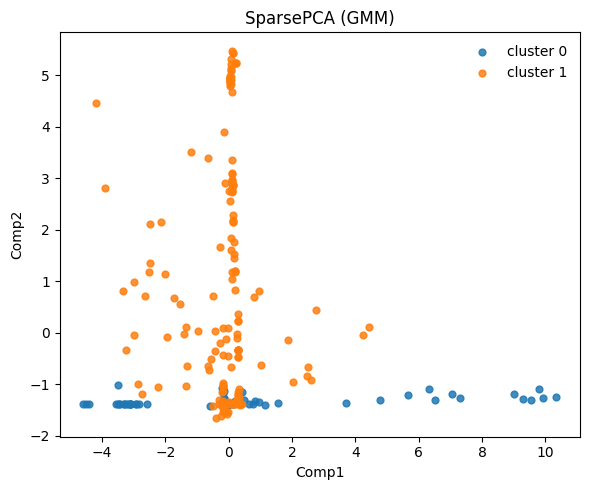

In [ ]:
# Plot convergence of cluster parameters
print("=== CLUSTER PARAMETER CONVERGENCE ===")

# Plot scalar_K convergence (if we track it)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot LSE convergence
axes[0].plot(subtyping_em.lse_history, marker='o', markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('LSE')
axes[0].set_title('LSE Convergence')
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot beta convergence (mean absolute change)
if hasattr(subtyping_em, 'beta_history'):
    beta_changes = np.mean(np.abs(np.diff(subtyping_em.beta_history, axis=1)), axis=0)
    axes[1].plot(beta_changes, marker='o', markersize=4)
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Mean |Δβ|')
    axes[1].set_title('Beta Convergence')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_yscale('log')

plt.tight_layout()
plt.show()


In [ ]:
# Final visualization: compare true trajectories with predicted cluster trajectories
print("=== COMPARING TRUE vs PREDICTED TRAJECTORIES ===")

fig, axes = plt.subplots(n_subtypes, 2, figsize=(14, 5*n_subtypes))

for subtype in range(n_subtypes):
    # True trajectory
    f_true = f_list[subtype]
    scalar_K_true = scalar_K_list[subtype]
    trajectory_true = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_true,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_true
    )
    
    # Predicted trajectory
    f_pred = subtyping_em.cluster_f[subtype]
    scalar_K_pred = subtyping_em.cluster_scalar_K[subtype]
    trajectory_pred = solve_system(
        x0=np.zeros(n_biomarkers),
        f=f_pred,
        K=K,
        t_span=t_span,
        scalar_K=scalar_K_pred
    )
    
    # Plot true
    for b in range(n_biomarkers):
        axes[subtype, 0].plot(t_span, trajectory_true[b], label=f'Biomarker {b}', alpha=0.7)
    axes[subtype, 0].set_title(f'True Subtype {subtype} Trajectory')
    axes[subtype, 0].set_xlabel('Time')
    axes[subtype, 0].set_ylabel('Biomarker Value')
    axes[subtype, 0].grid(True, alpha=0.3)
    
    # Plot predicted
    for b in range(n_biomarkers):
        axes[subtype, 1].plot(t_span, trajectory_pred[b], label=f'Biomarker {b}', alpha=0.7)
    axes[subtype, 1].set_title(f'Predicted Subtype {subtype} Trajectory')
    axes[subtype, 1].set_xlabel('Time')
    axes[subtype, 1].set_ylabel('Biomarker Value')
    axes[subtype, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("The SubtypingEM algorithm has successfully:")
print("1. Estimated global s parameter")
print("2. Assigned patients to clusters")
print("3. Estimated cluster-specific f and scalar_K parameters")
print("4. Estimated patient-specific beta values")


Clusters: 2
Adjusted Rand Index (vs. true): 0.4337
Silhouette (in reduced space): 0.2008
Mean cluster entropy: 0.0130
